In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline


In [3]:
from sklearn.datasets import make_blobs

In [4]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [5]:
X

array([[ 0.32960165, -2.4109405 ],
       [ 8.39404133,  4.82117311],
       [ 7.41415778,  7.97409289],
       ...,
       [ 6.42527732,  8.15223696],
       [ 5.72686365,  7.81504734],
       [ 6.98371352,  8.00747802]], shape=(1000, 2))

In [6]:
y

array([1, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 0, 2, 1, 1, 1, 1, 2, 1, 0, 1, 1,
       2, 2, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 1, 2, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 0,
       0, 0, 0, 1, 1, 2, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2,
       0, 0, 1, 2, 0, 0, 2, 0, 0, 2, 1, 1, 1, 1, 2, 2, 1, 0, 2, 0, 0, 0,
       0, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 2, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 2, 1, 1, 1, 1,
       0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 2, 1, 1, 0, 2, 1, 2, 1, 1, 0,
       0, 2, 1, 2, 0, 0, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 0, 0, 0, 2, 2,
       2, 0, 2, 0, 0, 1, 2, 1, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 2, 1, 0,
       2, 1, 0, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 2, 1, 2, 2, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 2, 1, 1, 1, 1, 0,
       0, 1, 2, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 1, 0, 2,
       2, 1, 1, 2, 2, 0, 2, 1, 2, 1, 1, 2, 1, 2, 0,

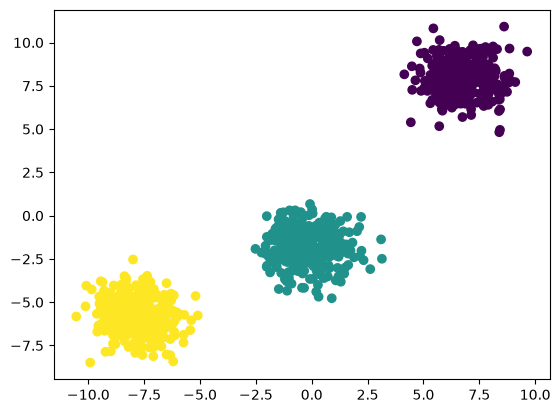

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [18]:
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [19]:
wcss

[1340.0000000000011,
 256.2395199158487,
 36.44203787857644,
 32.6884865940477,
 29.064079516707757,
 23.765415435618145,
 21.59957944432813,
 19.14716623883029,
 18.27284741567972,
 17.421133780365]

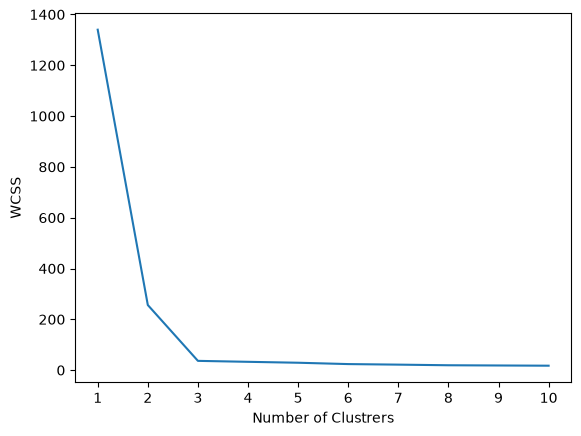

In [21]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [24]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 1, 0, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0, 1, 1,
       0, 2, 1, 1, 1, 0, 1, 0, 2, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0, 2,
       2, 1, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1,
       0, 2, 2, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 2,
       0, 2, 2, 2, 1, 0, 0, 1, 0, 1, 2, 1, 0, 1, 1, 1, 0, 0, 2, 1, 1, 1,
       2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 0, 1, 0, 0, 2, 0, 0, 1,
       0, 1, 1, 2, 0, 0, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 1, 0,
       2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0, 2, 0, 2, 2, 1, 1, 0, 1, 0, 1, 2,
       0, 1, 0, 0, 0, 2, 1, 2, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 2,
       0, 1, 2, 1, 0, 1, 0, 0, 2, 2, 0, 1, 2, 0, 2, 2, 1, 2, 0, 2, 0, 2,
       0, 1, 2, 0, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 0,
       1, 0, 0, 1, 1, 2, 2, 1, 1, 1, 0, 0, 2, 2, 1, 2, 1, 1, 2, 1, 2, 0,
       0, 1, 2, 2, 1, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 1, 2, 1, 2, 0, 1,
       0, 0, 2, 2, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2, 2,

In [25]:
y_pred = kmeans.predict(X_test_scaled)

In [26]:
y_pred

array([2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 0, 2, 2, 2, 2, 0, 0, 2, 1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 1, 2, 0,
       0, 2, 1, 1, 2, 1, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0,
       1, 1, 2, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 2, 0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 2, 1, 0, 0, 1, 1, 2, 2, 2,
       0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 0, 2, 1, 0, 0, 2, 1, 2, 2, 2,
       2, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 1, 1, 2, 0, 2, 1, 2, 1, 0, 2,
       0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 1, 1, 1, 0, 1, 1, 0, 2, 0,
       2, 2, 0, 1, 2, 2, 1, 2, 0, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1, 0, 0, 2,
       0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0,
       2, 0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 0, 0, 0, 2, 2, 0, 2, 2, 2, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 1, 2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 2, 0, 2, 0,
       2, 2, 2, 1, 1, 0, 1, 0, 2, 2, 0, 1, 0, 1, 0,

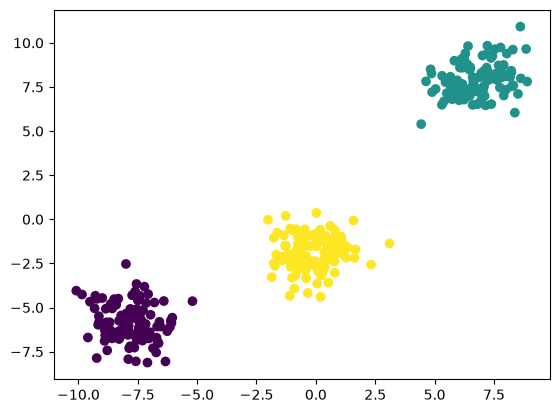

In [29]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [30]:
!pip install kneed

In [31]:
from kneed import KneeLocator

In [32]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [33]:
kl.elbow

np.int64(3)

In [34]:
from sklearn.metrics import silhouette_score

In [35]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [36]:
silhouette_coefficients

[0.7379520577410009,
 0.8146264147126068,
 0.6505845594614216,
 0.4691234090225527,
 0.5046076428041129,
 0.4966745751666842,
 0.3260362691939213,
 0.3120674129434346,
 0.32476436747698345]

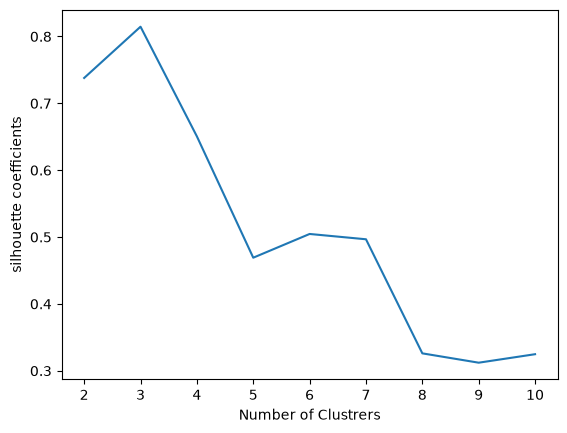

In [39]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("silhouette coefficients")
plt.show()